In [1]:
import sys

sys.path.append("..")

In [2]:
import matplotlib
import matplotlib.ticker as tkr
import matplotlib.pyplot as plt
import numpy as np
import torch

from dataset.cyclone import CycloneDataset

In [3]:
# Loading data
dataset = CycloneDataset(
    active_keys=["re", "im"],
    path="/restricteddata/ukaea/gyrokinetics/preprocessed",
    split="train",
    random_seed=42,
    normalization=None,
    spatial_ifft=False,
    bundle_seq_length=1,
    trajectories=["cyclone7_2.h5"],
    partial_holdouts=None,
)

## 4x4 ground truth

In [122]:
def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def plot4x4(x1, title="", mode="mean", slice="mid", use_colorbar=False):
    labels = ["v_{par}", "v_{\mu}", "s", "k_x", "k_y"]
    comb = torch.combinations(torch.arange(5), 2).tolist()

    fig, ax = plt.subplots(5, 5, figsize=(16 + (3 if use_colorbar else 0), 16))

    if use_colorbar:
        fig.subplots_adjust(hspace=0.35)
    else:
        fig.subplots_adjust(hspace=0.03, wspace=0.02)

    for i in range(5):
        for j in range(5):
            ax_ij = ax[i, j]
            if j == 0:
                ax_ij.remove()
                continue
            if i == 4:
                ax_ij.remove()
                continue
            if [i, j] not in comb:
                ax_ij.set_frame_on(False)
            ax_ij.tick_params(labelleft=False, labelbottom=False)
            ax_ij.set_xticks([])
            ax_ij.set_yticks([])

    # fig.tight_layout()
    fig.suptitle(title)
    c_map = matplotlib.colormaps["RdBu"]

    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])

        if mode == "mean":
            xx = x1[0].mean(other)
        elif mode == "std":
            c_map = matplotlib.colormaps["turbo"]
            xx = x1[0].std(other)
        else:
            xx = x1[0].permute(i, j, *other).numpy()
            if slice == "start":
                a, b, c = 2, xx.shape[2 + 1] // 2, 2
            if slice == "mid":
                a, b, c = xx.shape[2] // 2, xx.shape[2 + 1] // 2, xx.shape[2 + 2] // 2
            if slice == "end":
                a, b, c = -2, xx.shape[2 + 1] // 2, -2

            xx = xx[:, :, a, b, c]

        ax_ij = ax[i, j]
        # Plot x1 and xp side by side
        vmin, vmax = xx.min(), xx.max()
        im1 = ax_ij.matshow(xx, cmap=c_map, vmin=vmin, vmax=vmax)

        if use_colorbar:
            cbar = fig.colorbar(
                im1,
                ax=[ax_ij],
                format=tkr.FormatStrFormatter("%.1E"),
                pad=0.02,
                fraction=0.05,
            )
            # Optionally set ticks/labels, e.g. just min and max
            cbar.set_ticks([vmin, (vmin + vmax) / 2, vmax])
            cbar.ax.tick_params(labelsize=12)

        if j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3) or (i == 3 and j == 4):
            ax_ij.set_ylabel(rf"${labels[i]}$", fontsize=42)

        if i == 3 or j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3):
            ax_ij.set_xlabel(rf"${labels[j]}$", fontsize=42)

        ax_ij.set_xticks([])
        ax_ij.set_yticks([])
        ax_ij.tick_params(labelleft=False, labelbottom=False)
        force_aspect(ax_ij)

    return fig

<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2970766/3898086581.py:8: SyntaxWarning: invalid escape sequence '\m'
  labels = ["v_{par}", "v_{\mu}", "s", "k_x", "k_y"]


Ion temperature gradient 7.9, timestep: 1.9
Ion temperature gradient 7.9, timestep: 50.6


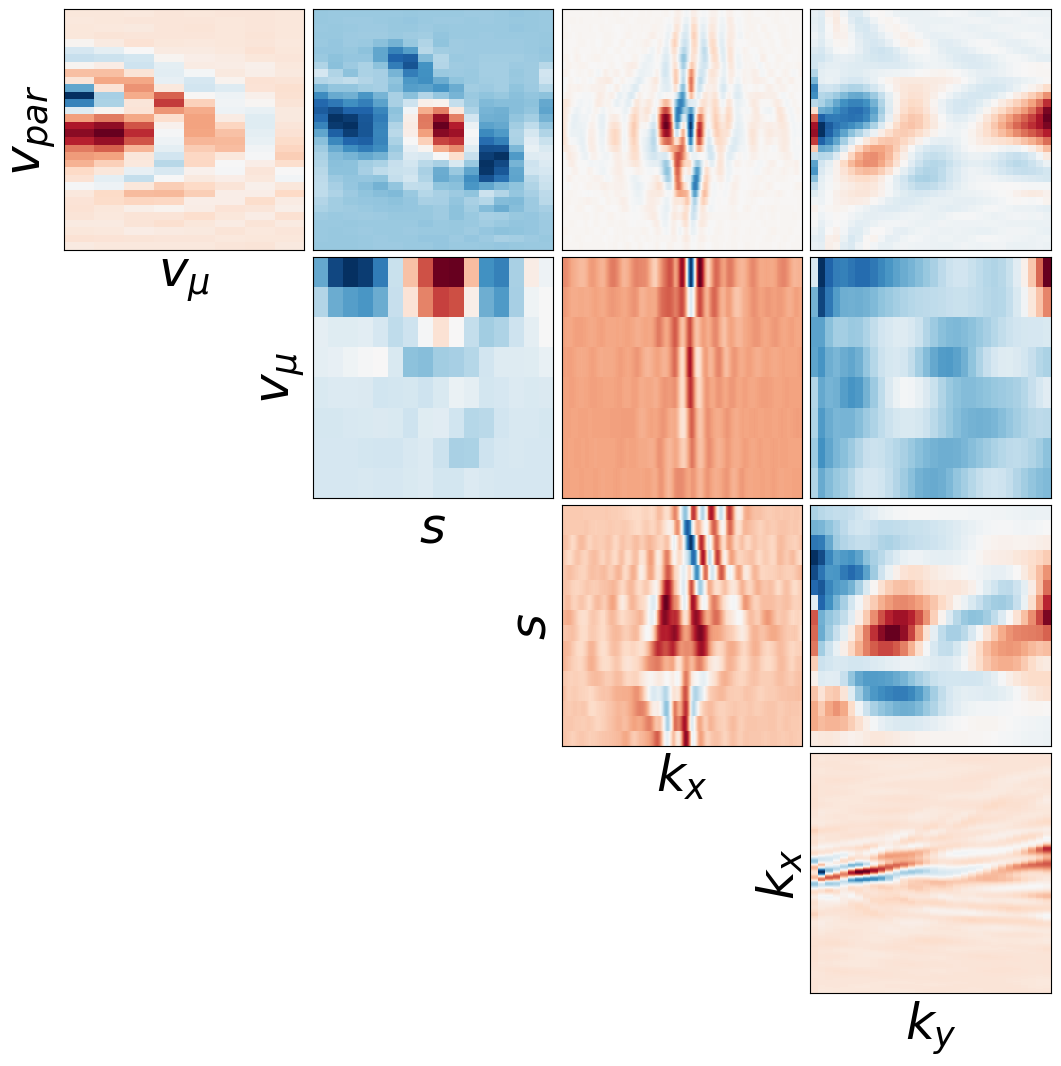

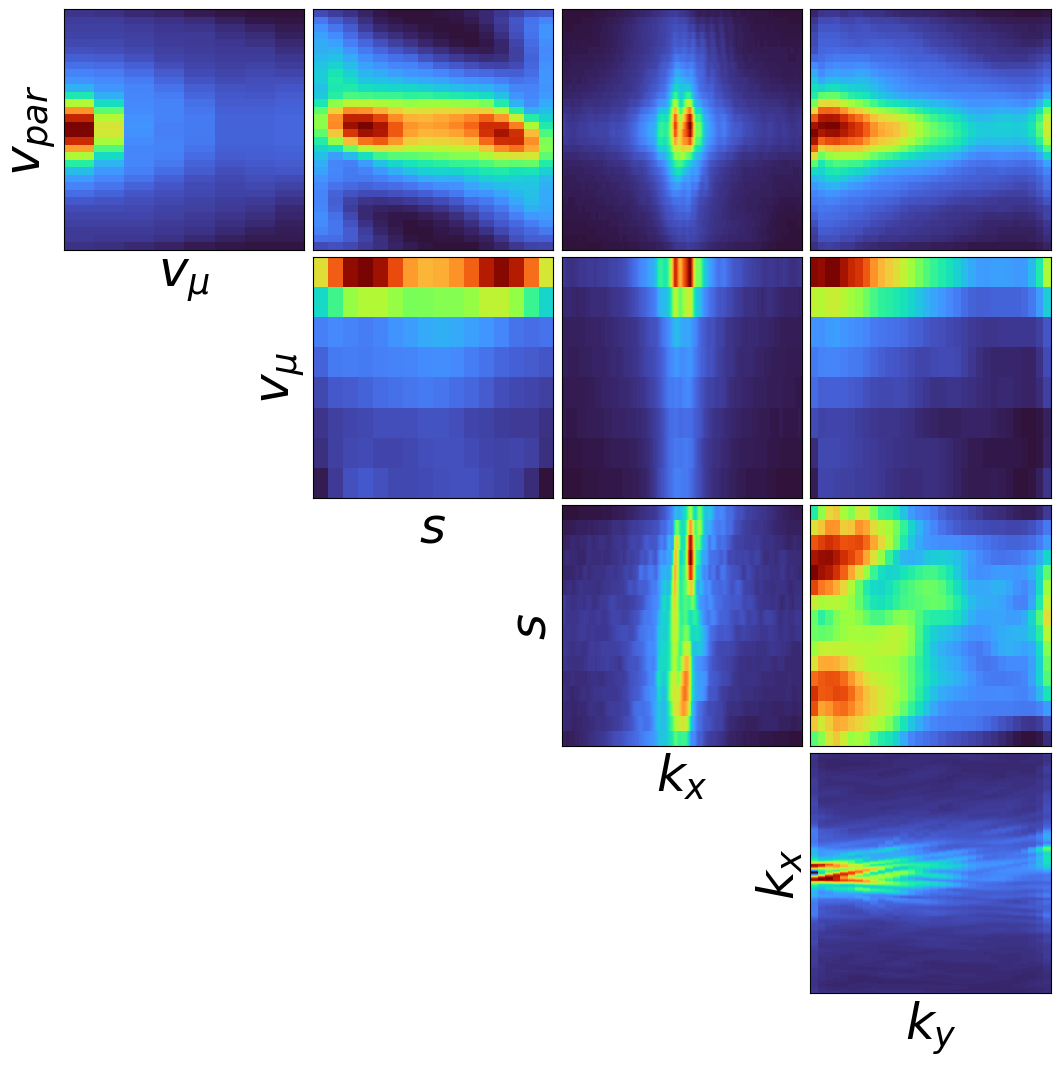

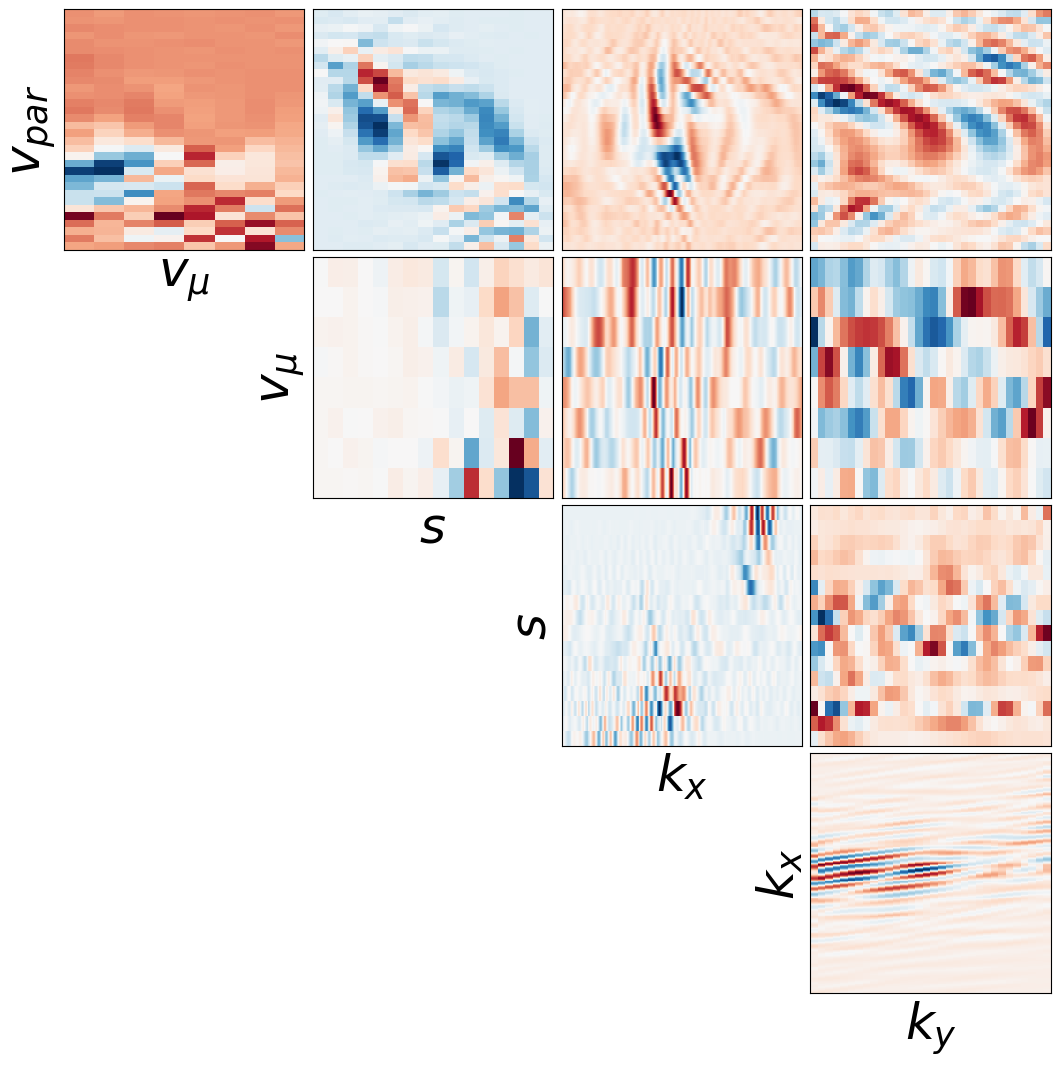

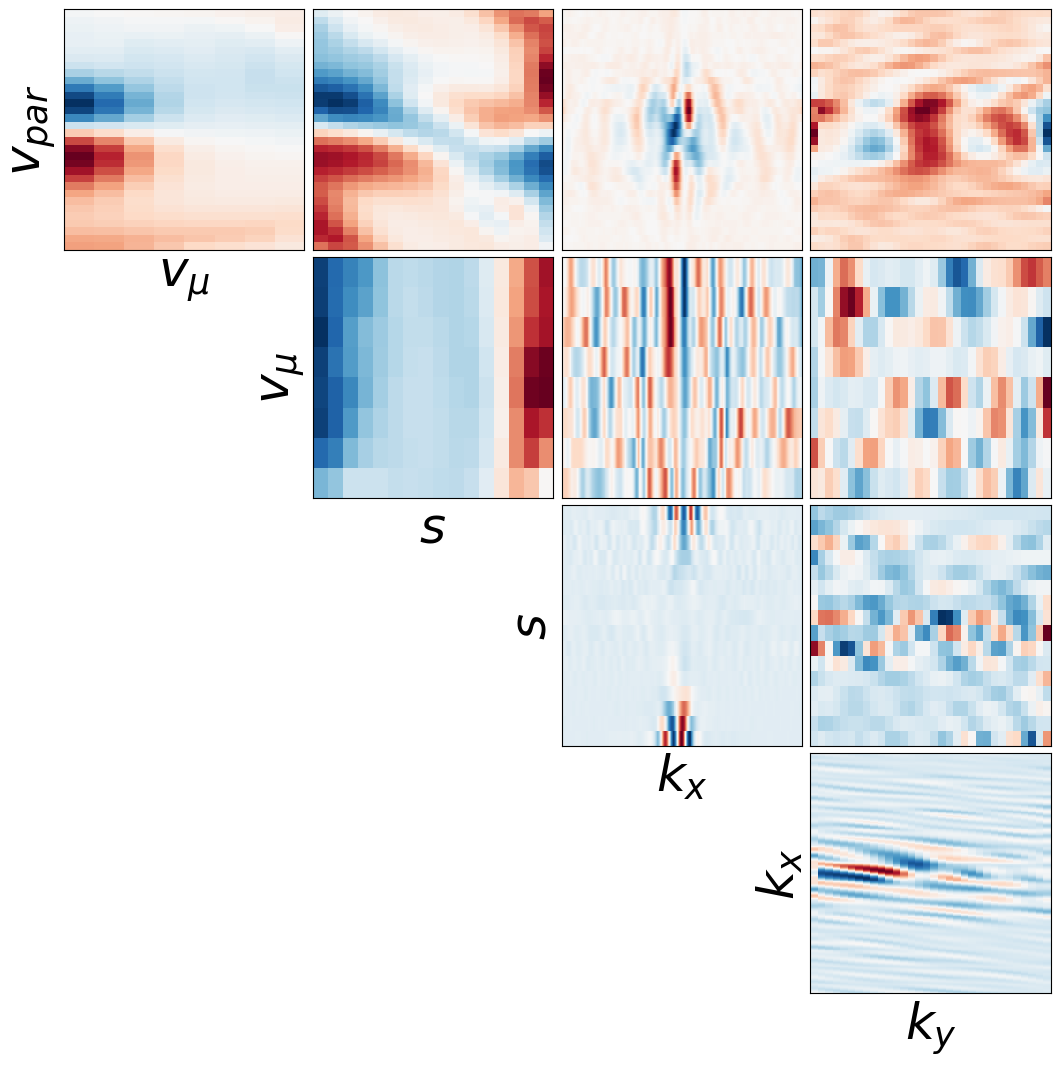

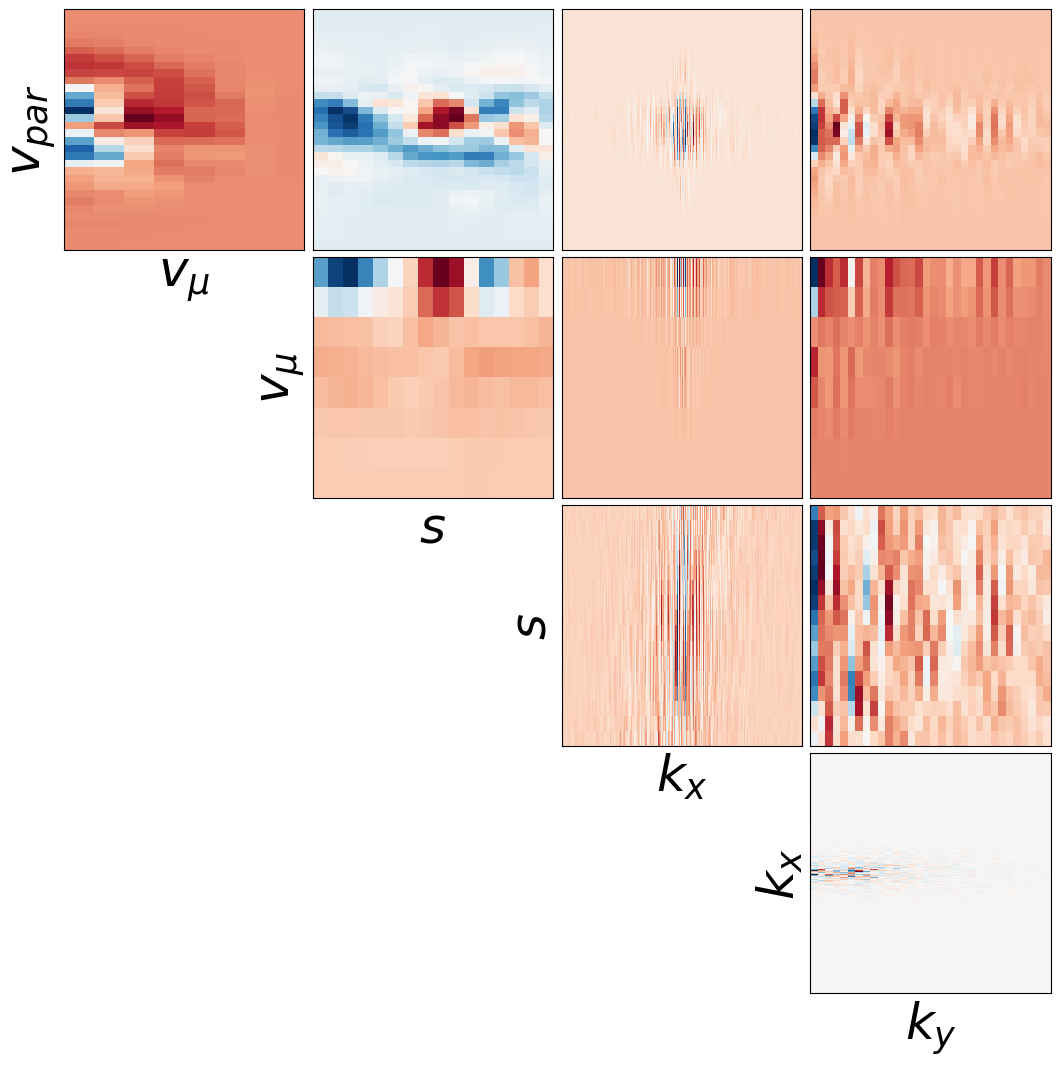

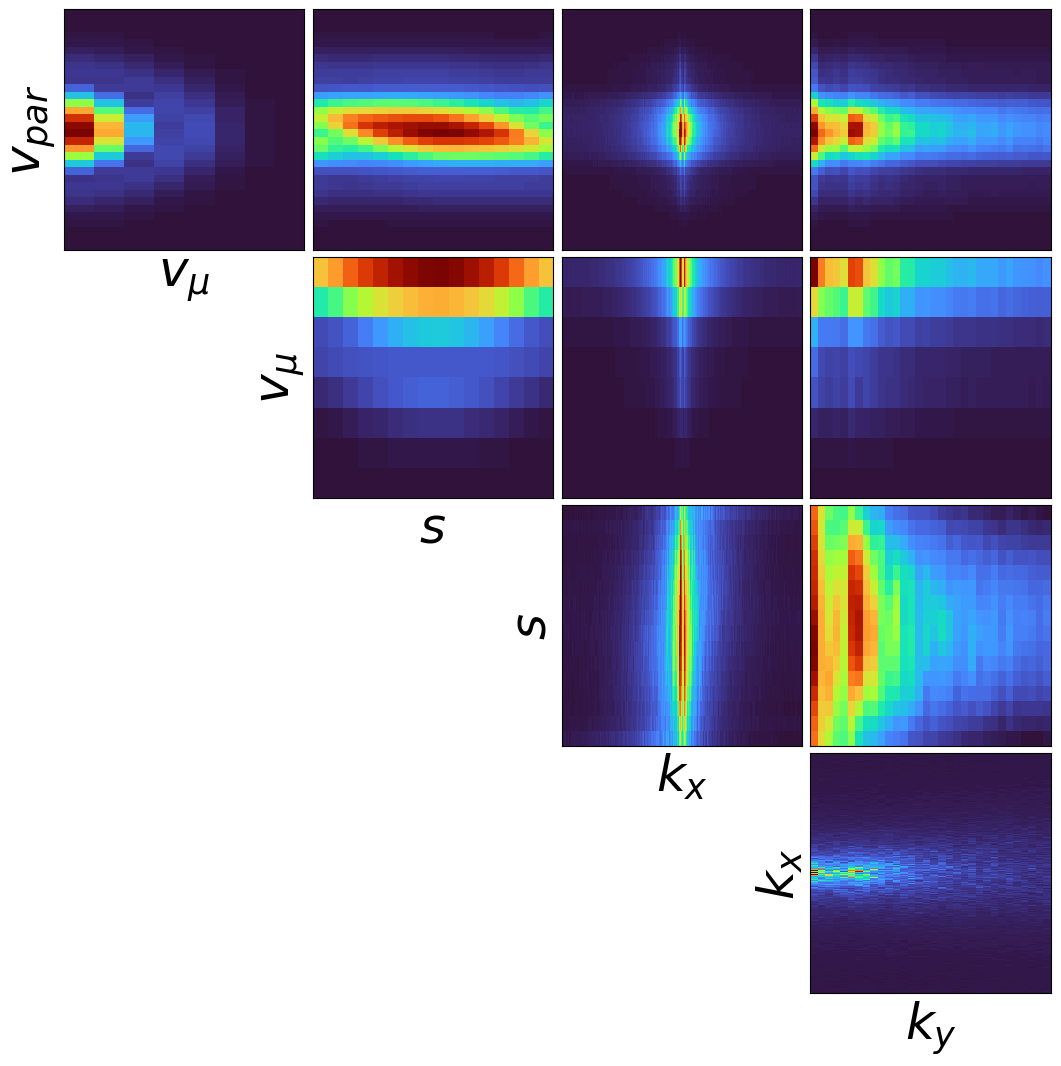

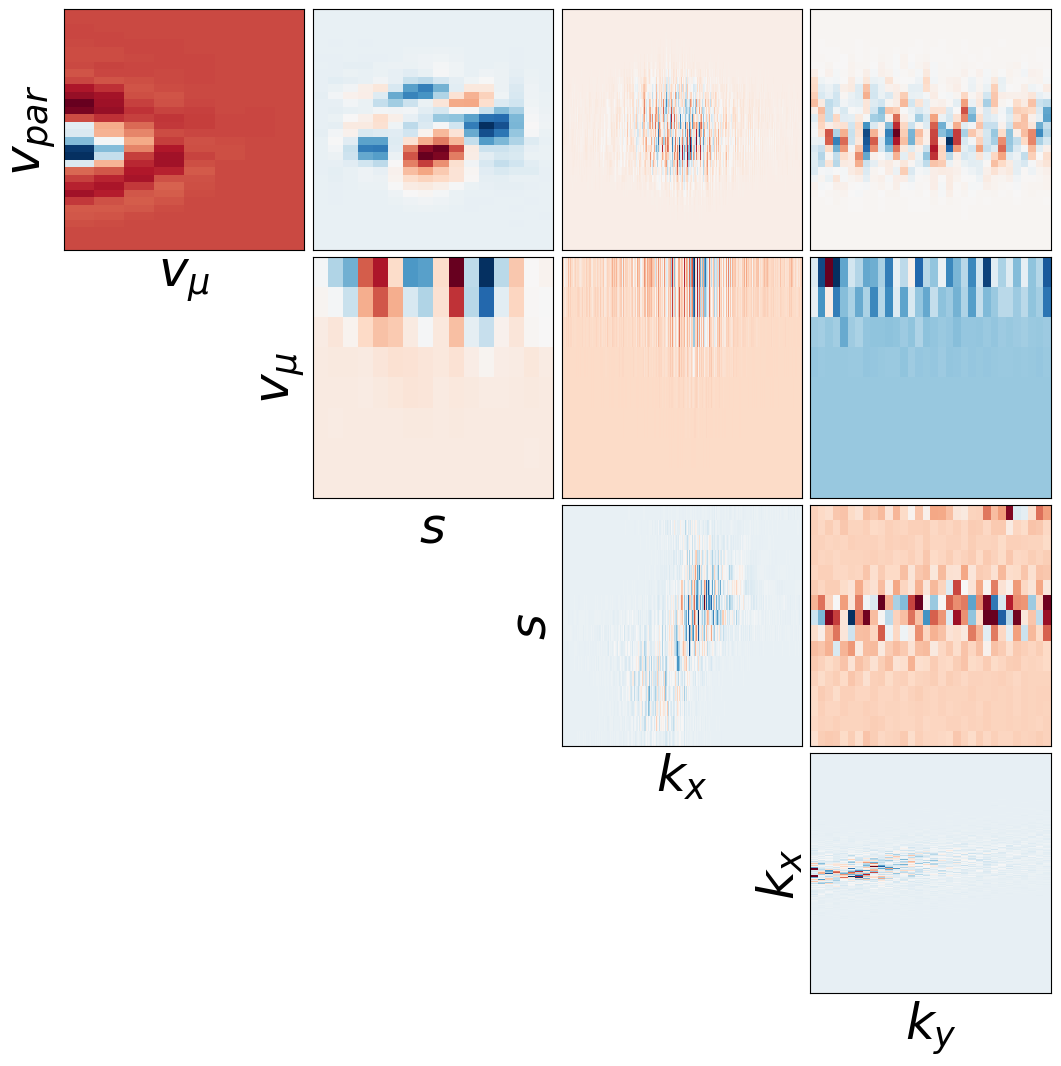

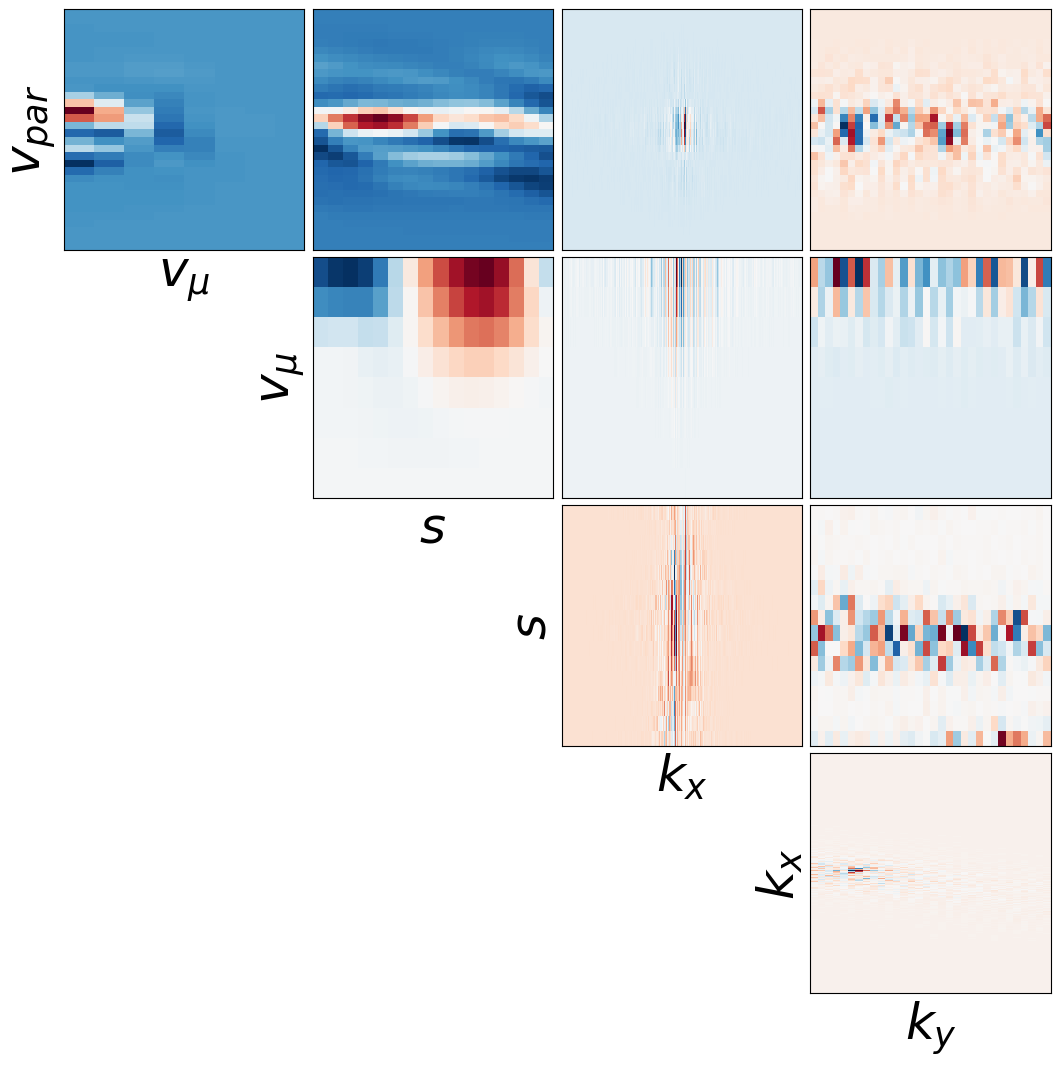

In [123]:
sample = dataset[1]
plot = plot4x4(sample.x, mode="mean", slice="end")
plot.savefig(
    f"5Dplots/compact_avg_{sample.itg.item():.1f}_{sample.timestep.item():.1f}.svg",
    bbox_inches="tight",
)
plot = plot4x4(sample.x, mode="std", slice="end")
plot.savefig(
    f"5Dplots/compact_std_{sample.itg.item():.1f}_{sample.timestep.item():.1f}.svg",
    bbox_inches="tight",
)

plot = plot4x4(sample.x, mode="slice", slice="end")
plot.savefig(
    f"5Dplots/compact_end_{sample.itg.item():.1f}_{sample.timestep.item():.1f}.svg",
    bbox_inches="tight",
)
plot = plot4x4(sample.x, mode="slice", slice="start")
plot.savefig(
    f"5Dplots/compact_start_{sample.itg.item():.1f}_{sample.timestep.item():.1f}.svg",
    bbox_inches="tight",
)
plot = plot4x4(sample.x, mode="slice", slice="mid")
plot.savefig(
    f"5Dplots/compact_mid_{sample.itg.item():.1f}_{sample.timestep.item():.1f}.svg",
    bbox_inches="tight",
)
print(
    f"Ion temperature gradient {sample.itg.item():.1f}, timestep: {sample.timestep.item():.1f}"
)
plt.close()

sample = dataset[50]
plot = plot4x4(sample.x, mode="mean", slice="end")
plot.savefig(
    f"5Dplots/compact_avg_{sample.itg.item():.1f}_{sample.timestep.item():.1f}.svg",
    bbox_inches="tight",
)
plot = plot4x4(sample.x, mode="std", slice="end")
plot.savefig(
    f"5Dplots/compact_std_{sample.itg.item():.1f}_{sample.timestep.item():.1f}.svg",
    bbox_inches="tight",
)

plot = plot4x4(sample.x, mode="slice", slice="end")
plot.savefig(
    f"5Dplots/compact_end_{sample.itg.item():.1f}_{sample.timestep.item():.1f}.svg",
    bbox_inches="tight",
)
plot = plot4x4(sample.x, mode="slice", slice="start")
plot.savefig(
    f"5Dplots/compact_start_{sample.itg.item():.1f}_{sample.timestep.item():.1f}.svg",
    bbox_inches="tight",
)
plot = plot4x4(sample.x, mode="slice", slice="mid")
plot.savefig(
    f"5Dplots/compact_mid_{sample.itg.item():.1f}_{sample.timestep.item():.1f}.svg",
    bbox_inches="tight",
)
print(
    f"Ion temperature gradient {sample.itg.item():.1f}, timestep: {sample.timestep.item():.1f}"
)
plt.close()

## 4x4 side by side

In [17]:
def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def plot4x4_sided(x1, x2, title="", mark_bad=False, mode="mean"):
    labels = ["v_{par}", "v_{\mu}", "s", "k_x", "k_y"]
    comb = torch.combinations(torch.arange(5), 2).tolist()
    print(comb)

    fig, ax = plt.subplots(5, 5, figsize=(30, 14))
    for i in range(5):
        for j in range(5):
            if j == 0:
                ax[i, j].remove()
                continue
            if i == 4:
                ax[i, j].remove()
                continue
            ax_ij = ax[i, j]
            # ax_ij.set_visible(False)                # hides the axis background and content
            ax_ij.set_frame_on(False)  # turns off the bounding box
            ax_ij.tick_params(
                labelleft=False, labelbottom=False
            )  # turns off tick labels
            ax_ij.set_xticks([])
            ax_ij.set_yticks([])

    # fig.tight_layout()
    fig.suptitle(title)
    c_map = matplotlib.colormaps["RdBu"]
    c_map.set_bad("k")

    for i, j in comb:
        other = tuple([o for o in range(5) if o != i and o != j])

        if average:
            x1_plot = x1[0].mean(other)
            x2_plot = x2[0].mean(other)
        else:
            x1_plot = torch.tensor(x1[0]).permute(i, j, *other).numpy()[:, :, 0, 0, 0]
            x2_plot = torch.tensor(x2[0]).permute(i, j, *other).numpy()[:, :, 0, 0, 0]

        if mark_bad:
            x1_std = x1.std(other)
            x2_std = x2.std(other)
            x1_plot[x1_std == 0] = np.nan
            x2_plot[x2_std == 0] = np.nan

        # Clear the axis and directly plot two images side by side
        ax_ij = ax[i, j]
        # _ = ax_ij.matshow(x1_plot)
        # force_aspect(ax_ij)
        # ax_ij.set_visible(False)                # hides the axis background and content
        # ax_ij.set_

        # cbar = fig.colorbar(_, ax=[ax_ij], format=tkr.FormatStrFormatter("%.2g"))

        # Get the position of the original axis
        pos = ax_ij.get_position()

        # Create two new axes within the same space as the original subplot
        # displ = pos.width / 2
        # width = 0.9 * (displ)  # Split the width into two halves
        # ax1 = fig.add_axes([pos.x0, pos.y0, width, pos.height])
        # ax2 = fig.add_axes([pos.x0 + displ, pos.y0, width, pos.height])
        plot_width = 0.475 * pos.width  # 40% each
        left_margin = 0.0 * pos.width  # 10% left
        right_margin = 0.0 * pos.width  # 10% right
        # assert left_margin + 2*plot_width + right_margin == pos.width

        # X coordinates:
        x_left_1 = pos.x0 + left_margin
        x_left_2 = x_left_1 + plot_width  # just to the right of ax1

        # The y, height are the same as pos
        y = pos.y0
        h = pos.height

        # Create ax1 and ax2
        ax1 = fig.add_axes([x_left_1, y, plot_width, h])
        ax2 = fig.add_axes([x_left_2, y, plot_width, h])

        # compute shared vmin and vmax
        vmin = min(x1_plot.min(), x2_plot.min())
        vmax = max(x1_plot.max(), x2_plot.max())

        # Plot x1 and xp side by side
        im1 = ax1.matshow(x1_plot, cmap=c_map, vmin=vmin, vmax=vmax)
        im2 = ax2.matshow(x2_plot, cmap=c_map, vmin=vmin, vmax=vmax)

        # -------------------------------------------------------------
        # 3) Create a single colorbar shared by both ax1 and ax2
        # -------------------------------------------------------------
        # We can pick one of the images (im1 or im2) as the "mappable."
        # cbar = fig.colorbar(im1, ax=[ax1, ax2], format=tkr.FormatStrFormatter("%.2g"), pad=0.01, fraction=0.05)
        cbar = fig.colorbar(
            im1, ax=[ax_ij], format=tkr.FormatStrFormatter("%.2g"), pad=0, fraction=0.05
        )

        # Optionally set ticks/labels, e.g. just min and max
        cbar.set_ticks([vmin, (vmin + vmax) / 2, vmax])
        cbar.ax.tick_params(labelsize=12)

        # cbar1 = fig.colorbar(im1, ax=ax1, format=tkr.FormatStrFormatter("%.2g"))
        # cbar2 = fig.colorbar(im2, ax=ax2, format=tkr.FormatStrFormatter("%.2g"))

        # cbar1.set_ticks([x1_plot.min(), x1_plot.max()])
        # cbar2.set_ticks([x2_plot.min(), x2_plot.max()])

        if i == 0:
            # Set axis labels
            ax1.set_title(r"Predicted", fontsize=14)
            ax2.set_title(r"Ground Truth", fontsize=14)

        # ax1.set_xlabel(labels[j])
        # ax1.set_ylabel(labels[i])
        # ax2.set_xlabel(labels[j])
        # ax2.set_ylabel(labels[i])
        # ax_ij.set_ylabel(labels[i])
        # ax_ij.set_xlabel(labels[j])
        # print(f"{i=}, {j=}")
        if j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3) or (i == 3 and j == 4):
            ax_ij.set_ylabel(rf"${labels[i]}$", fontsize=14)

        if i == 3 or j == 1 or (i == 1 and j == 2) or (i == 2 and j == 3):
            ax_ij.set_xlabel(rf"${labels[j]}$", fontsize=14)

        # pos1 = ax1.get_position()
        # print(pos1.x1 - pos1.x0)
        # pos2 = ax2.get_position()
        # # X-center between left edge of ax1 and right edge of ax2
        # xmid = 0.5 * (pos1.x0 + pos2.x1)
        # # A bit below the subplots (adjust as needed)
        # y_label_pos = pos1.y0 - 0.01

        # # Add text in figure coordinates
        # fig.text(xmid, y_label_pos, labels[j], ha="center", va="top")

        # Remove axis ticks and labels
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax2.set_xticks([])
        ax2.set_yticks([])
        ax1.tick_params(labelleft=False, labelbottom=False)
        ax2.tick_params(labelleft=False, labelbottom=False)
        # Force aspect ratio
        force_aspect(ax1)
        force_aspect(ax2)

        # Set only one tick at the maximum value for both axes
        # ax1.set_xticks([x1_plot.shape[1] - 1])
        # ax1.set_yticks([x1_plot.shape[0] - 1])
        # ax2.set_xticks([x2_plot.shape[1] - 1])
        # ax2.set_yticks([x2_plot.shape[0] - 1])
    # fig.tight_layout()

    return fig

In [18]:
plot = plot4x4_sided(pred, gt)

In [8]:
plot.savefig("distribution_1.svg", bbox_inches="tight")

## Main figure 1.0 (3 timesteps)

In [236]:
pred_t = []
gt_t = []
for t in range(3):
    sample = dataset[t]
    pred = sample.x
    gt = sample.y
    pred_t.append(pred)
    gt_t.append(gt)

In [247]:
def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def plot_selected_sided(pred_t, gt_t, title=""):
    labels = [r"v_{\parallel}", r"\mu", r"s", r"k_x", r"k_y"]

    selected_comb = [(0, 1), (1, 2), (2, 3), (3, 4)]

    fig, ax = plt.subplots(len(pred_t), 4, figsize=(16.5, 2 * len(pred_t)))
    for t in range(len(pred_t)):
        for k in range(4):
            ax_ij = ax[t, k]
            ax_ij.set_frame_on(False)
            ax_ij.tick_params(labelleft=False, labelbottom=False)
            ax_ij.set_xticks([])
            ax_ij.set_yticks([])

    arrow_ax = fig.add_axes(
        [0.905, 0.05, 0.02, 0.9]
    )  # Adjust position and size for the long arrow
    arrow_ax.annotate(
        "",
        xy=(0.5, 0.1),
        xytext=(0.5, 0.9),
        arrowprops=dict(facecolor="black", width=1.6, headwidth=8, headlength=10),
        ha="center",
        va="center",
        color="black",
    )
    arrow_ax.axis("off")

    # fig.tight_layout()
    fig.suptitle(title)
    c_map = matplotlib.colormaps["RdBu"]
    c_map.set_bad("k")

    for t in range(len(pred_t)):
        x1 = pred_t[t]
        x2 = gt_t[t]
        for k, (i, j) in enumerate(selected_comb):
            other = tuple([o for o in range(5) if o != i and o != j])

            x1_plot = x1[0].mean(other)
            x2_plot = x2[0].mean(other)

            ax_ij = ax[t, k]

            pos = ax_ij.get_position()

            plot_width = 0.5 * pos.width  # 40% each
            left_margin = 0.0 * pos.width  # 10% left

            # X coordinates:
            x_left_1 = pos.x0 + left_margin
            x_left_2 = x_left_1 + plot_width  # just to the right of ax1

            # The y, height are the same as pos
            y = pos.y0
            h = pos.height

            # Create ax1 and ax2
            ax1 = fig.add_axes([x_left_1, y, plot_width, h])
            ax2 = fig.add_axes([x_left_2, y, plot_width, h])

            # compute shared vmin and vmax
            vmin = min(x1_plot.min(), x2_plot.min())
            vmax = max(x1_plot.max(), x2_plot.max())

            # Plot x1 and xp side by side
            ax1.matshow(x1_plot, cmap=c_map, vmin=vmin, vmax=vmax)
            ax2.matshow(x2_plot, cmap=c_map, vmin=vmin, vmax=vmax)

            # Set axis labels
            if t == 0:
                ax1.set_title(r"$\delta f_{pred}$", fontsize=32)
                ax2.set_title(r"$\delta f_{GT}$", fontsize=32)

            if t == len(pred_t) - 1:
                ax_ij.set_xlabel(rf"${labels[j]}$", fontsize=32)

            if t == len(pred_t) // 2:
                ax_ij.set_ylabel(
                    rf"${labels[i]}$", fontsize=32, rotation=0, ha="right", y=0.35
                )

            # Remove axis ticks and labels
            ax1.set_xticks([])
            ax1.set_yticks([])
            ax2.set_xticks([])
            ax2.set_yticks([])
            ax1.tick_params(labelleft=False, labelbottom=False)
            ax2.tick_params(labelleft=False, labelbottom=False)
            # Force aspect ratio
            force_aspect(ax1)
            force_aspect(ax2)

        y_pos = 0.79 - t * (0.9 / len(pred_t))
        txt = arrow_ax.text(
            0.12, y_pos, rf"$t_{t}$", fontsize=22, va="center", ha="left", color="black"
        )
        txt.set_bbox(dict(facecolor="white", alpha=1.0))

    return fig

In [248]:
plot_t0 = plot_selected_sided(pred_t, gt_t)
plot_t0.savefig("dft.svg", bbox_inches="tight")

## Flux trace

In [ ]:
import os

directory = "/system/user/publicdata/gyrokinetics/raw/cyclone4_2"
# Input file names
filename = "Poten00000200"

pot_path = os.path.join(directory, filename)

# load data files
time = np.loadtxt(os.path.join(directory, "time.dat"))
fluxes = np.loadtxt(os.path.join(directory, "fluxes.dat"))


fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(time[0:180], fluxes[0:180, 1], lw=3, c=(32 / 255, 70 / 255, 125 / 255))
ax.scatter(
    np.linspace(0, 30, 10),
    np.random.uniform(0, 25, 10),
    marker="x",
    c=(182 / 255, 72 / 255, 66 / 255),
)
ax.grid()
ax.set_xlabel(r"$t$", fontsize=20)
ax.set_ylabel(r"$\int \delta f$", fontsize=20)
ax.tick_params(labelsize=14)
fig.savefig("fluxes.svg")

## Flux trace vs ion temperature gradient

[5.9, 14.9, 7.9, 9.9, 2.9] [8, 12, 7, 10, 11]


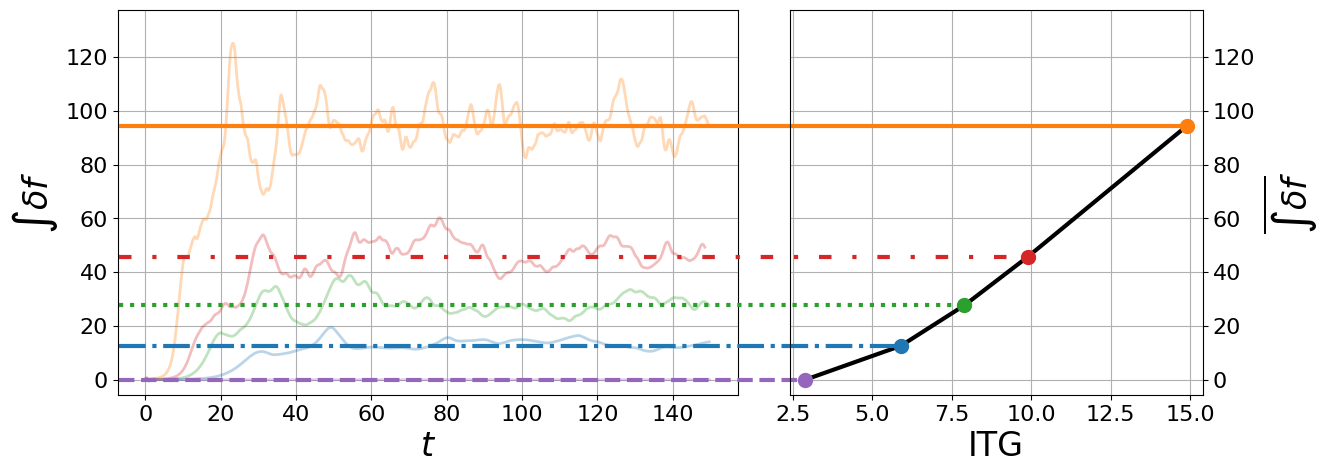

In [15]:
import os
import re
from matplotlib import colormaps


def parse_input_dat(file_path):
    parsed_data = {}
    with open(file_path, "r") as file:
        content = file.read()
    # split the content by section headers (e.g., &SPECIES, &SPCGENERAL, etc.)
    sections = re.split(r"&\w+", content)
    # get all the headers by finding the section names
    section_headers = re.findall(r"&(\w+)", content)
    # remove comments
    sections = [
        section.strip() for section in sections if section[0] != "!" and section.strip()
    ]
    for header, section in zip(section_headers, sections):
        section_dict = {}
        params = re.findall(r"(\w+)\s*=\s*([-\d\.e\w]+)", section)
        for param, value in params:
            try:
                section_dict[param] = (
                    float(value) if "e" in value or "." in value else int(value)
                )
            except ValueError:
                section_dict[param] = value.strip()
        while header in parsed_data:
            header = f"{header}0"
        parsed_data[header] = section_dict

    return parsed_data


file_idxs = [8, 12, 7, 10, 11]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [6, 4]}
)
fig.subplots_adjust(wspace=0.1)
cmap = colormaps["tab10"]
line_styles = ["--", "-.", "-", ":", (0, (3, 5, 1, 5))]

used_styles = []
ion_temp_grads = []
avg_fluxes = []
flux_values = []
for f_idx, i in enumerate(file_idxs):
    directory = f"/restricteddata/ukaea/gyrokinetics/raw/cyclone{i}_2"
    # Input file names
    filename = "Poten00000200"

    pot_path = os.path.join(directory, filename)

    # load data files
    time = np.loadtxt(os.path.join(directory, "time.dat"))
    fluxes = np.loadtxt(os.path.join(directory, "fluxes.dat"))

    config = parse_input_dat(f"{directory}/input.dat")
    ion_temp_grad = config["SPECIES"]["rlt"]

    idxs = time < 150
    avg_idxs = np.bitwise_and(20 < time, time < 150)
    color = cmap(f_idx)
    line_style = line_styles[(f_idx - 4) % len(line_styles)]
    used_styles.append(f_idx)
    ax1.plot(
        time[idxs],
        fluxes[idxs, 1],
        lw=2,
        label=f"ITG={ion_temp_grad:.1f}",
        c=color,
        alpha=0.3,
    )
    # Add a straight line for the average flux
    avg_flux = np.mean(fluxes[avg_idxs, 1])
    # ax1.axhline(
    #     avg_flux,
    #     color=cmap(i),
    #     linestyle=line_style,
    #     alpha=1.0,
    #     linewidth=3,
    #     label=f"Avg ITG={ion_temp_grad:.1f}"
    # )
    ion_temp_grads.append(ion_temp_grad)
    avg_fluxes.append(avg_flux)
    flux_values.extend(list(fluxes[idxs, 1]))

print(ion_temp_grads, file_idxs)

y_min = min(flux_values)
y_max = max(flux_values)

ax1.set_ylim(y_min - 5, y_max + y_max * 0.1)
ax2.set_ylim(y_min - 5, y_max + y_max * 0.1)
ax2.set_xlim(min(ion_temp_grads) - 0.5, max(ion_temp_grads) + 0.5)

ax1.grid()
ax1.set_xlabel(r"$t$", fontsize=24)
ax1.set_ylabel(r"$\int \delta f$", fontsize=24)
ax1.tick_params(labelsize=16)

sorted_indices = np.argsort(ion_temp_grads)
ion_temp_grads = np.array(ion_temp_grads)[sorted_indices]
used_styles = np.array(used_styles)[sorted_indices]
avg_fluxes = np.array(avg_fluxes)[sorted_indices]
file_idxs = np.array(file_idxs)[sorted_indices]
ax2.plot(
    ion_temp_grads,
    avg_fluxes,
    "o-",
    lw=3,
    color="k",
    label="Ion Temp Grad vs Avg Flux",
)

for itg, avg_flux, f_idx in zip(ion_temp_grads, avg_fluxes, used_styles):
    ax2.hlines(
        avg_flux,
        xmin=-18.70,
        # xmin=-6.35,
        xmax=itg,
        color=cmap(f_idx),
        linestyle=line_styles[(f_idx - 4) % len(line_styles)],
        alpha=1.0,
        linewidth=3,
        clip_on=False,
    )
    # mid_point = 3.05
    # t = ax2.text(mid_point, avg_flux, f"{itg:.1f}", color=cmap(i), fontsize=14, ha="center", va="center")
    # t.set_bbox(dict(facecolor="white", alpha=0.8, edgecolor="black"))
    ax2.plot([itg], [avg_flux], "o", color=cmap(f_idx), ms=10)

ax2.grid()
ax2.set_xlabel(r"ITG", fontsize=24)
ax2.tick_params(labelsize=16)
ax2.set_ylabel(r"$\overline{\int \delta f}$", fontsize=24)
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

fig.savefig("fluxes_itg.pdf", bbox_inches="tight")

## Poteltial plots

In [118]:
from matplotlib import colormaps

time = np.loadtxt(os.path.join(directory, "time.dat"))
sgrid = np.loadtxt(os.path.join(directory, "sgrid"))
xphi = np.loadtxt(os.path.join(directory, "xphi"))
yphi = np.loadtxt(os.path.join(directory, "yphi"))
fluxes = np.loadtxt(os.path.join(directory, "fluxes.dat"))
kyspec = np.loadtxt(os.path.join(directory, "kyspec"))
krho = np.loadtxt(os.path.join(directory, "krho"))
vpgr = np.loadtxt(os.path.join(directory, "vpgr.dat"))
vperp = np.loadtxt(os.path.join(directory, "vperp.dat"))

filename = "Poten00000380"
a = np.loadtxt(os.path.join(directory, filename))
ns = sgrid.shape[1] if len(sgrid.shape) > 1 else sgrid.shape[0]

# number of x, y grid points (in real space)
nx, ny = xphi.shape[1], xphi.shape[0]

phi = np.reshape(a, (nx, ns, ny), order="F")

# Plot real space potential
fig, ax = plt.subplots(1, 2, figsize=(12, 3))

c_map = colormaps["plasma"]
fig.subplots_adjust(wspace=0.05)
ax[0].matshow(np.squeeze(phi[:, 8, :]).T, cmap=c_map)
ax[0].set_title(r"$\phi_{pred}$", fontsize=24)
ax[0].set_xlabel(
    r"$x_{\phi}$",
    fontsize=20,
    x=ax[0].get_position().x0 + ax[0].get_position().width + ax[1].get_position().x0,
)
ax[0].set_ylabel(r"$y_{\phi}$", fontsize=20)
ax[0].set_xticks([])
ax[0].set_yticks([])

filename = "Poten00000400"
a = np.loadtxt(os.path.join(directory, filename))
phi = np.reshape(a, (nx, ns, ny), order="F")

c_map = colormaps["plasma"]
ax[1].matshow(np.squeeze(phi[:, 8, :]).T, cmap=c_map)
ax[1].set_title(r"$\phi_{GT}$", fontsize=24)
# ax[1].set_xlabel(r"$x_{\phi}$", fontsize=20)
ax[1].set_xticks([])
ax[1].set_yticks([])
fig.savefig("potentials.svg", bbox_inches="tight")

## Main figure 2.0 (5 timesteps + potential evolution)

In [398]:
pred_t = []
gt_t = []
for t in range(5):
    sample = dataset[t]
    pred = sample.x
    pot = sample.y_poten
    gt = sample.y
    pred_t.append((pred, pot))
    gt_t.append((gt, pot + 5))

In [429]:
def force_aspect(ax, aspect=1):
    im = ax.get_images()
    extent = im[0].get_extent()
    ax.set_aspect(abs((extent[1] - extent[0]) / (extent[3] - extent[2])) / aspect)


def plot_selected_sided_w_pot(pred_t, gt_t, title=""):
    labels = [r"v_{\parallel}", r"\mu", r"s", r"k_x", r"k_y"]

    selected_comb = [(0, 1), (1, 2), (2, 3), (3, 4)]

    fig, ax = plt.subplots(len(pred_t), 4, figsize=(26, 3 * len(pred_t)))
    for t in range(len(pred_t)):
        for k in range(4):
            ax_ij = ax[t, k]
            ax_ij.set_frame_on(False)
            ax_ij.tick_params(labelleft=False, labelbottom=False)
            ax_ij.set_xticks([])
            ax_ij.set_yticks([])

    arrow_ax = fig.add_axes(
        [0.905, 0.01, 0.02, 0.95]
    )  # Adjust position and size for the long arrow
    arrow_ax.annotate(
        "",
        xy=(0.5, 0.1),
        xytext=(0.5, 0.9),
        arrowprops=dict(facecolor="black", width=1.6, headwidth=8, headlength=10),
        ha="center",
        va="center",
        color="black",
    )
    arrow_ax.axis("off")

    pot_ax = [
        fig.add_axes(
            [
                ax[t, -1].get_position().x1 + 0.06,
                ax[t, -1].get_position().y0,
                ax[t, -1].get_position().width + 0.15,
                ax[t, -1].get_position().height,
            ]
        )
        for t in range(len(pred_t))
    ]

    for p in pot_ax:
        p.set_frame_on(False)
        p.tick_params(labelleft=False, labelbottom=False)
        p.set_xticks([])
        p.set_yticks([])

    # fig.tight_layout()
    fig.suptitle(title)
    c_map = matplotlib.colormaps["RdBu"]
    c_map.set_bad("k")

    for t in range(len(pred_t)):
        x1 = pred_t[t][0]
        x2 = gt_t[t][0]

        for k, (i, j) in enumerate(selected_comb):
            other = tuple([o for o in range(5) if o != i and o != j])

            x1_plot = x1[0].mean(other)
            x2_plot = x2[0].mean(other)

            ax_ij = ax[t, k]

            pos = ax_ij.get_position()

            plot_width = 0.5 * pos.width  # 40% each
            left_margin = 0.0 * pos.width  # 10% left

            # X coordinates:
            x_left_1 = pos.x0 + left_margin
            x_left_2 = x_left_1 + plot_width  # just to the right of ax1

            # The y, height are the same as pos
            y = pos.y0
            h = pos.height

            # Create ax1 and ax2
            ax1 = fig.add_axes([x_left_1, y, plot_width, h])
            ax2 = fig.add_axes([x_left_2, y, plot_width, h])

            # compute shared vmin and vmax
            vmin = min(x1_plot.min(), x2_plot.min())
            vmax = max(x1_plot.max(), x2_plot.max())

            # Plot x1 and xp side by side
            ax1.matshow(x1_plot, cmap=c_map, vmin=vmin, vmax=vmax)
            ax2.matshow(x2_plot, cmap=c_map, vmin=vmin, vmax=vmax)

            # Set axis labels
            if t == 0:
                ax1.set_title(r"$\delta f_{pred}$", fontsize=32)
                ax2.set_title(r"$\delta f_{GT}$", fontsize=32)

            if t == len(pred_t) - 1:
                ax_ij.set_xlabel(rf"${labels[j]}$", fontsize=32)

            if t == len(pred_t) // 2:
                ax_ij.set_ylabel(
                    rf"${labels[i]}$", fontsize=32, rotation=0, ha="right", y=0.35
                )

            # Remove axis ticks and labels
            ax1.set_xticks([])
            ax1.set_yticks([])
            ax2.set_xticks([])
            ax2.set_yticks([])
            ax1.tick_params(labelleft=False, labelbottom=False)
            ax2.tick_params(labelleft=False, labelbottom=False)
            # Force aspect ratio
            force_aspect(ax1)
            force_aspect(ax2)

        abc = list(map(chr, range(97, 123)))
        y_pos = 0.85 - t * (0.85 / len(pred_t))
        txt = arrow_ax.text(
            0.12,
            y_pos,
            rf"$t_{abc[t]}$",
            fontsize=30,
            va="center",
            ha="left",
            color="black",
        )
        txt.set_bbox(dict(facecolor="white", alpha=1.0))

        phi1 = pred_t[t][1]
        phi2 = gt_t[t][1]

        x1_plot = x1[0].mean(other)
        x2_plot = x2[0].mean(other)

        ax_ij = pot_ax[t]

        pos = ax_ij.get_position()

        plot_width = 0.5 * pos.width  # 40% each
        left_margin = 0.0 * pos.width  # 10% left
        right_gap = 0.02 * pos.width

        # X coordinates:
        x_left_1 = pos.x0 + left_margin
        x_left_2 = x_left_1 + plot_width + right_gap  # just to the right of ax1

        # The y, height are the same as pos
        y = pos.y0
        h = pos.height

        # Create ax1 and ax2
        ax1 = fig.add_axes([x_left_1, y, plot_width, h])
        ax2 = fig.add_axes([x_left_2, y, plot_width, h])

        ax1.matshow(np.squeeze(phi1[:, 8, :]), cmap=matplotlib.colormaps["plasma"])
        ax1.set_xticks([])
        ax1.set_yticks([])

        ax2.matshow(np.squeeze(phi2[:, 8, :]), cmap=matplotlib.colormaps["plasma"])
        if t == 0:
            ax2.set_title(r"$\phi_{pred}$", fontsize=32, y=1.2)
            ax1.set_title(r"$\phi_{GT}$", fontsize=32, y=1.2)

        if t == len(pred_t) // 2:
            ax_ij.set_ylabel(r"$y_{\phi}$", fontsize=32)

        if t == len(pred_t) - 1:
            ax_ij.set_xlabel(r"$x_{\phi}$", fontsize=32)

        ax2.set_xticks([])
        ax2.set_yticks([])

        force_aspect(ax1, aspect=3.0)
        force_aspect(ax2, aspect=3.0)

    return fig

In [430]:
plot_t0 = plot_selected_sided_w_pot(pred_t, gt_t)
plot_t0.savefig("dft_w_pot.svg", bbox_inches="tight")